In [154]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Machine learning
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecasting models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plot style
sns.set(style="whitegrid")


In [155]:
# Load CSV
df = pd.read_csv("seattle-weather.csv")

# Convert date to datetime and set index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Quick look
df.head()


,precipitation,temp_max,temp_min,wind,weather
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,drizzle
2012-01-02,10.9,10.6,2.8,4.5,rain
2012-01-03,0.8,11.7,7.2,2.3,rain
2012-01-04,20.3,12.2,5.6,4.7,rain
2012-01-05,1.3,8.9,2.8,6.1,rain


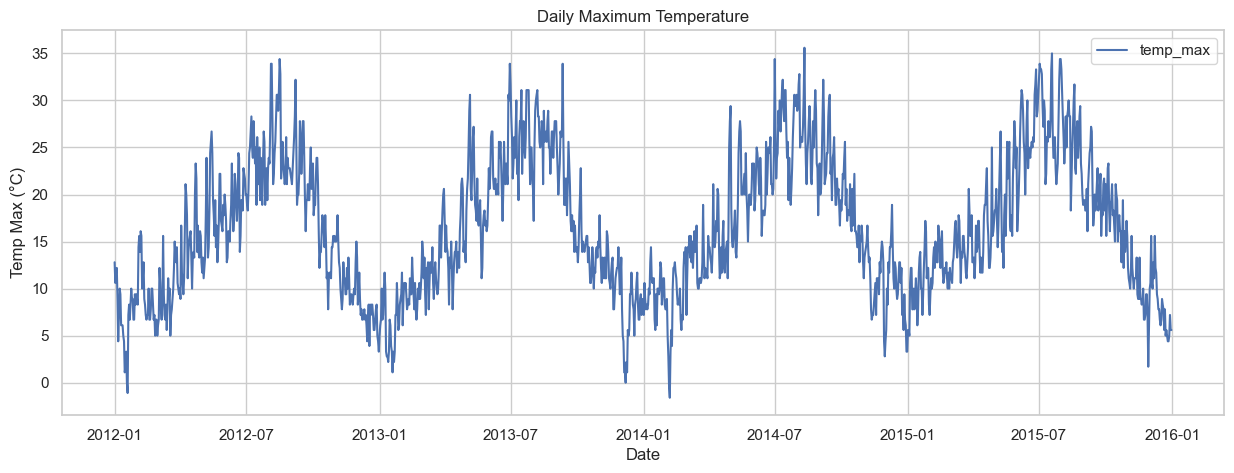

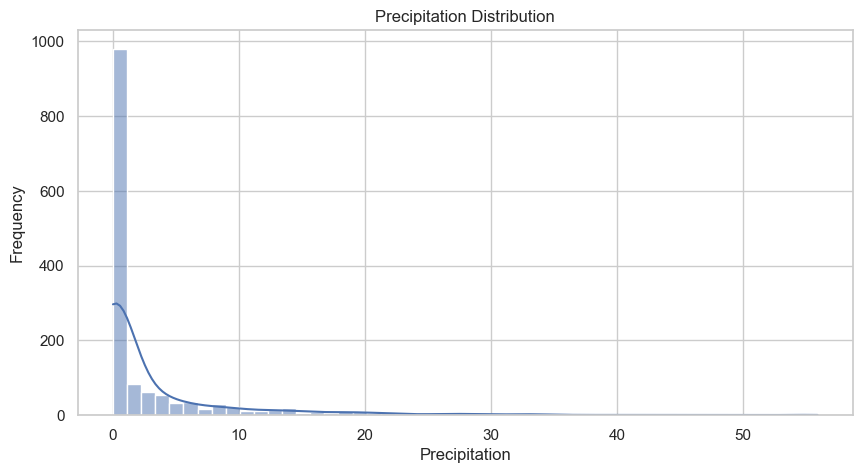

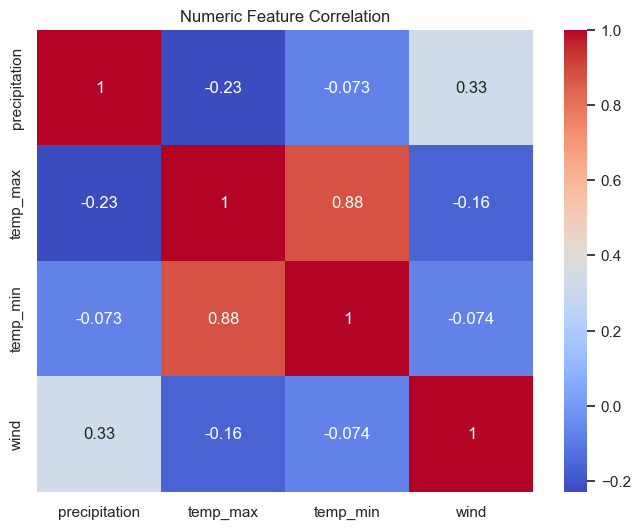

In [156]:
# ===== LINE PLOT: Temperature =====
plt.figure(figsize=(15,5))
plt.plot(df['temp_max'], label='temp_max')
plt.title('Daily Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Temp Max (°C)')
plt.legend()
plt.show()

# ===== HISTOGRAM: Precipitation =====
plt.figure(figsize=(10,5))
sns.histplot(df['precipitation'], bins=50, kde=True)
plt.title('Precipitation Distribution')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.show()

# ===== CORRELATION HEATMAP (Fixed) =====

# Encode weather categorical to numeric
numeric_df = df.select_dtypes(include=['float64','int64'])

# Plot correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Numeric Feature Correlation')
plt.show()




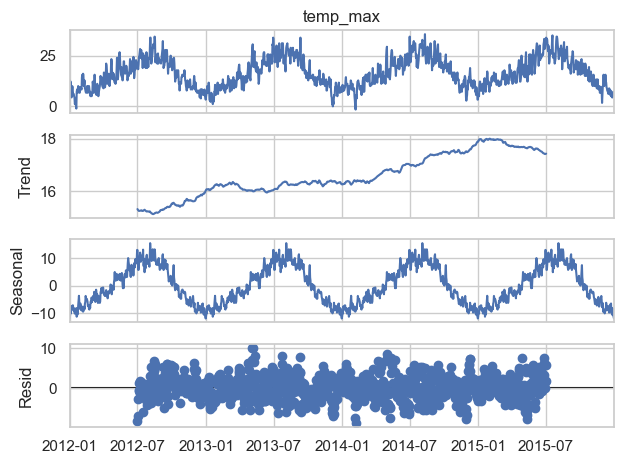

In [157]:
# Decompose temp_max
result = seasonal_decompose(df['temp_max'], model='additive', period=365)
result.plot()
plt.show()


In [158]:
# Handle missing values
df = df.fillna(method='ffill')

# Encode weather categorical
le = LabelEncoder()
df['weather_encoded'] = le.fit_transform(df['weather'])

# Extract time features
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['day_of_year'] = df.index.dayofyear


In [159]:
# Lag features
for lag in [1,7,30]:
    df[f'temp_max_lag_{lag}'] = df['temp_max'].shift(lag)
    df[f'precipitation_lag_{lag}'] = df['precipitation'].shift(lag)

# Rolling statistics
df['temp_max_roll7'] = df['temp_max'].rolling(7).mean()
df['temp_max_roll30'] = df['temp_max'].rolling(30).mean()

# Drop rows with NaNs due to lag/rolling
df = df.dropna()

df.head()


,precipitation,temp_max,temp_min,wind,weather,weather_encoded,year,month,day,day_of_week,day_of_year,temp_max_lag_1,precipitation_lag_1,temp_max_lag_7,precipitation_lag_7,temp_max_lag_30,precipitation_lag_30,temp_max_roll7,temp_max_roll30
date,,,,,,,,,,,,,,,,,,,
2012-01-31,1.8,9.4,6.1,3.9,rain,2,2012,1,31,1,31,8.3,3.6,10.0,8.6,12.8,0.0,8.328571,6.863333
2012-02-01,13.5,8.9,3.3,2.7,rain,2,2012,2,1,2,32,9.4,1.8,8.9,8.1,10.6,10.9,8.328571,6.806667
2012-02-02,0.0,8.3,1.7,2.6,sun,4,2012,2,2,3,33,8.9,13.5,8.9,4.8,11.7,0.8,8.242857,6.693333
2012-02-03,0.0,14.4,2.2,5.3,sun,4,2012,2,3,4,34,8.3,0.0,6.7,0.0,12.2,20.3,9.342857,6.766667
2012-02-04,0.0,15.6,5.0,4.3,sun,4,2012,2,4,5,35,14.4,0.0,6.7,0.0,8.9,1.3,10.614286,6.990000


In [160]:
# Train: 2012-2014, Test: 2015
train = df[df.index < '2015-01-01']
test = df[df.index >= '2015-01-01']

X_train = train.drop('temp_max', axis=1)
y_train = train['temp_max']

X_test = test.drop('temp_max', axis=1)
y_test = test['temp_max']


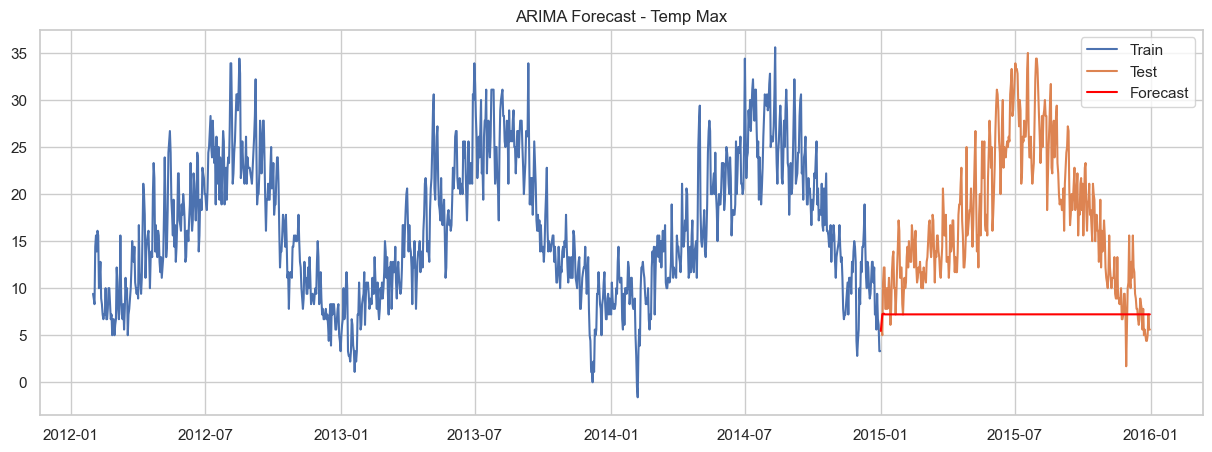

MAE: 10.40, RMSE: 12.56


In [161]:
# Only temp_max series for ARIMA
train_series = train['temp_max']
test_series = test['temp_max']

# Fit ARIMA (adjust p,d,q as needed)
model = ARIMA(train_series, order=(5,1,2))
arima_result = model.fit()

# Forecast
forecast = arima_result.forecast(steps=len(test_series))

# Plot
plt.figure(figsize=(15,5))
plt.plot(train_series, label='Train')
plt.plot(test_series, label='Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast - Temp Max')
plt.legend()
plt.show()

# Metrics
mae_a = mean_absolute_error(test_series, forecast)
rmse_a = np.sqrt(mean_squared_error(test_series, forecast))
print(f'MAE: {mae_a:.2f}, RMSE: {rmse_a:.2f}')


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0275 - val_loss: 0.0059
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0096 - val_loss: 0.0058
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0096 - val_loss: 0.0061
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0092 - val_loss: 0.0056
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0097 - val_loss: 0.0055
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0105 - val_loss: 0.0051
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0086 - val_loss: 0.0058
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0089 - val_loss: 0.0050
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0081 - val_loss: 0.0050
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0076 - val_loss: 0.0043
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0071 - val_loss: 0.0044
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.0

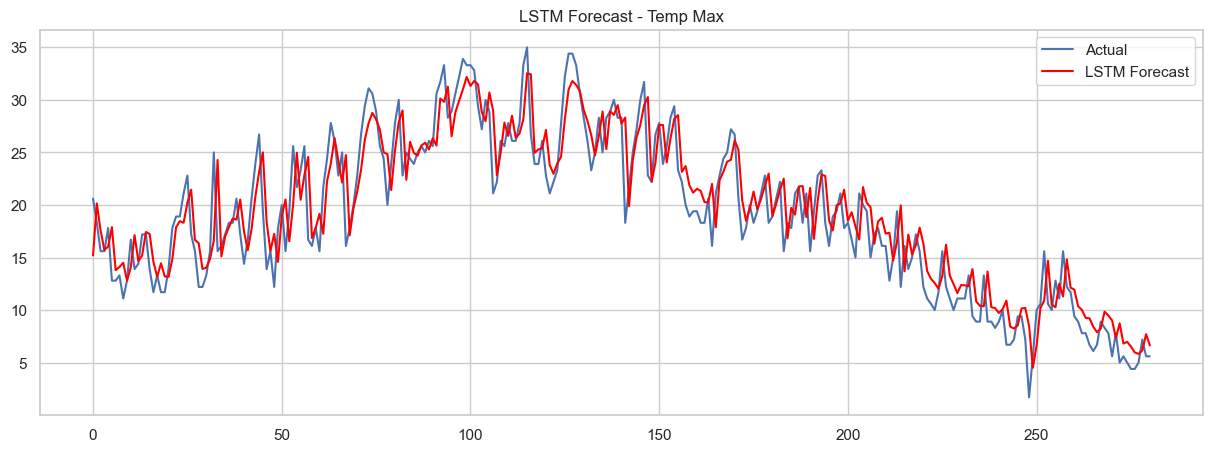

LSTM MAE: 2.29, RMSE: 2.92


In [162]:
# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['temp_max']])

# Create sequences
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# Train-test split
split = int(len(X) * 0.8)
X_train_lstm, X_test_lstm = X[:split], X[split:]
y_train_lstm, y_test_lstm = y[:split], y[split:]

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# Build LSTM model
model = Sequential()
model.add(LSTM(200, return_sequences=True, input_shape=(SEQ_LENGTH,1)))
model.add(LSTM(250))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

# Plot
plt.figure(figsize=(15,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='LSTM Forecast', color='red')
plt.title('LSTM Forecast - Temp Max')
plt.legend()
plt.show()

# Metrics
mae_l = mean_absolute_error(y_test_actual, y_pred)
rmse_l = np.sqrt(mean_squared_error(y_test_actual, y_pred))
print(f'LSTM MAE: {mae_l:.2f}, RMSE: {rmse_l:.2f}')


In [164]:
# You can create a summary table of MAE/RMSE for ARIMA, Prophet, LSTM
results = pd.DataFrame({
    'Model': ['ARIMA','LSTM'],
    'MAE': [mae_a, mae_l],  # replace with respective metrics
    'RMSE': [rmse_a, rmse_l]
})
results


,Model,MAE,RMSE
0,ARIMA,10.39886,12.556858
1,LSTM,2.29329,2.920530


In [165]:
# Save LSTM model
model.save('temp_max_lstm.h5')

# Save scaler
import joblib
joblib.dump(scaler, 'scaler_temp_max.save')


['scaler_temp_max.save']